# Part 3: NLP and Sequence Modelling Mini Project

**Dataset:** `customer_support_text_classification.csv`  
**Goal:** Build an NLP pipeline to classify customer support messages by sentiment (positive / neutral / negative).

---
### Tasks
1. Dataset Understanding
2. Text Preprocessing
3. Text Vectorization
4. Baseline Model
5. Sequence Model (LSTM Architecture)
6. Attention and Transformer Reflection

## Setup — Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy scikit-learn matplotlib seaborn tensorflow

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print('Libraries imported successfully.')

Libraries imported successfully.


---
## Task 1: Dataset Understanding

Load and analyse the text dataset. Include:
- Number of records
- Target labels / classes
- Sample text records
- Average text length
- Class distribution

In [3]:
# Load the dataset
df = pd.read_csv('customer_support_text_classification.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1500, 6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [4]:
# Basic info
print('=== Column Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Basic Statistics ===')
print(df.describe())

=== Column Data Types ===
ticket_id             str
channel               str
customer_message      str
sentiment_label       str
word_count          int64
urgent_flag         int64
dtype: object

=== Missing Values ===
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64

=== Basic Statistics ===
        word_count  urgent_flag
count  1500.000000  1500.000000
mean     12.722667     0.266667
std       3.691455     0.442364
min       7.000000     0.000000
25%      10.000000     0.000000
50%      12.000000     0.000000
75%      15.000000     1.000000
max      26.000000     1.000000


=== Target Label Distribution ===
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

=== Percentage Distribution ===
sentiment_label
neutral     34.93%
negative    33.13%
positive    31.93%
Name: count, dtype: str


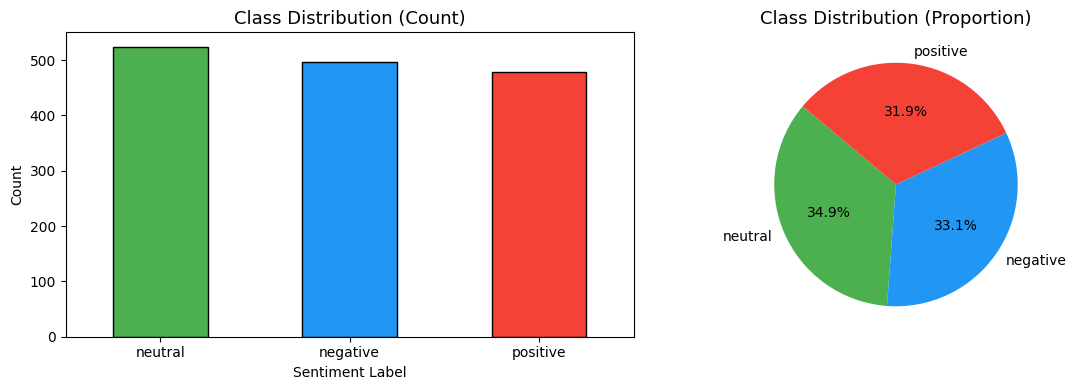

In [5]:
# Target label distribution
print('=== Target Label Distribution ===')
label_counts = df['sentiment_label'].value_counts()
print(label_counts)
print()
print('=== Percentage Distribution ===')
print((label_counts / len(df) * 100).round(2).astype(str) + '%')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4CAF50', '#2196F3', '#F44336']
label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Sample records per class
print('=== Sample Messages Per Class ===')
for label in ['positive', 'neutral', 'negative']:
    print(f'\n--- {label.upper()} ---')
    samples = df[df['sentiment_label'] == label]['customer_message'].head(2).tolist()
    for i, s in enumerate(samples, 1):
        print(f'  {i}. {s}')

=== Sample Messages Per Class ===

--- POSITIVE ---
  1. The refund process was fast and convenient. I appreciate the quick response.
  2. I am satisfied with the plan and would recommend it to others. My ticket number is 99198.

--- NEUTRAL ---
  1. I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  2. I need information about the payment process.

--- NEGATIVE ---
  1. My refund is still pending and this experience is frustrating. My ticket number is 33927.
  2. My refund is still pending and this experience is frustrating.


=== Word Count Statistics ===
count    1500.00
mean       12.72
std         3.69
min         7.00
25%        10.00
50%        12.00
75%        15.00
max        26.00
Name: word_count, dtype: float64

Average word count : 12.72
Max word count     : 26
Min word count     : 7


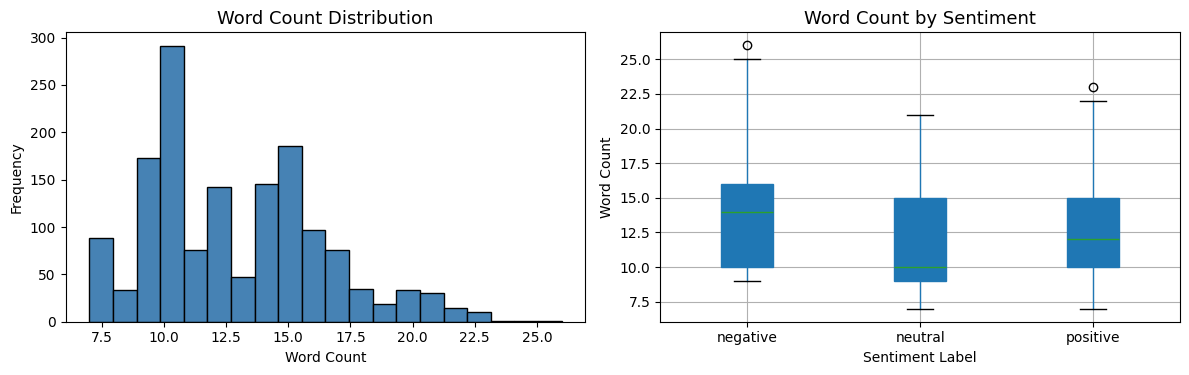

In [7]:
# Text length analysis
df['char_count'] = df['customer_message'].apply(len)

print('=== Word Count Statistics ===')
print(df['word_count'].describe().round(2))
print(f'\nAverage word count : {df["word_count"].mean():.2f}')
print(f'Max word count     : {df["word_count"].max()}')
print(f'Min word count     : {df["word_count"].min()}')

# Word count distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['word_count'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Word Count Distribution', fontsize=13)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

df.boxplot(column='word_count', by='sentiment_label', ax=axes[1],
           patch_artist=True)
axes[1].set_title('Word Count by Sentiment', fontsize=13)
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

=== Channel Distribution ===
channel
email     326
social    314
phone     296
chat      290
app       274
Name: count, dtype: int64

=== Urgent Flag Distribution ===
urgent_flag
0    1100
1     400
Name: count, dtype: int64


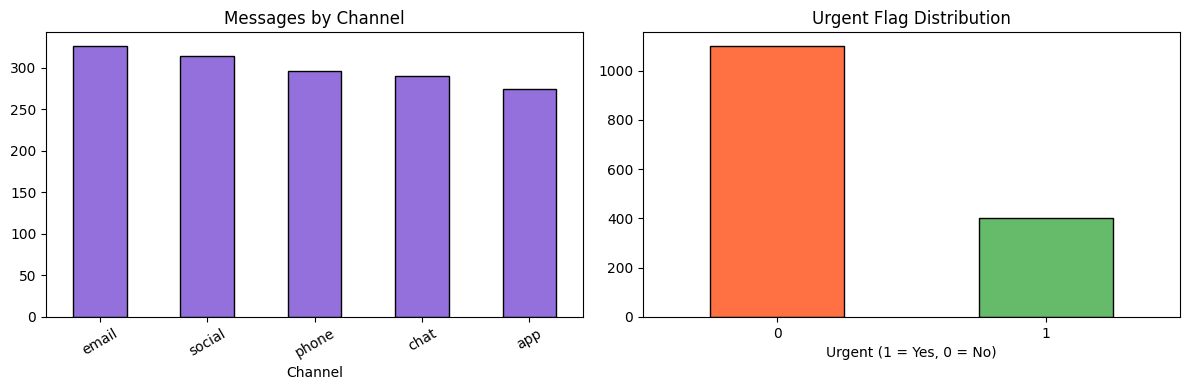

In [8]:
# Channel and urgent flag distributions
print('=== Channel Distribution ===')
print(df['channel'].value_counts())
print()
print('=== Urgent Flag Distribution ===')
print(df['urgent_flag'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['channel'].value_counts().plot(kind='bar', ax=axes[0],
    color='mediumpurple', edgecolor='black')
axes[0].set_title('Messages by Channel')
axes[0].set_xlabel('Channel')
axes[0].tick_params(axis='x', rotation=30)

df['urgent_flag'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#FF7043', '#66BB6A'], edgecolor='black')
axes[1].set_title('Urgent Flag Distribution')
axes[1].set_xlabel('Urgent (1 = Yes, 0 = No)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('channel_urgent_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 2: Text Preprocessing

Clean the text data. Preprocessing pipeline:
1. Lowercasing
2. Remove numbers
3. Remove punctuation / special characters
4. Tokenisation
5. Stopword removal
6. Padding / truncating sequences (for sequence models)

In [9]:
# Define stopwords
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','can','will','just','should','now','please','ticket','number',
    'would','could'
])

def clean_text(text):
    """Full text preprocessing pipeline."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 3. Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # 4. Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # 5. Tokenise and remove stopwords
    tokens = [t for t in text.split()
              if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

# Apply to dataset
df['clean_text'] = df['customer_message'].apply(clean_text)
df['clean_word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print('Preprocessing complete.')
print(f'Avg words BEFORE cleaning: {df["word_count"].mean():.2f}')
print(f'Avg words AFTER  cleaning: {df["clean_word_count"].mean():.2f}')

Preprocessing complete.
Avg words BEFORE cleaning: 12.72
Avg words AFTER  cleaning: 5.67


In [10]:
# Show before/after examples
print('=== Before vs After Preprocessing ===\n')
for i in range(5):
    print(f'[{i+1}] Original : {df["customer_message"].iloc[i]}')
    print(f'    Cleaned  : {df["clean_text"].iloc[i]}')
    print()

=== Before vs After Preprocessing ===

[1] Original : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
    Cleaned  : need information payment process respond soon possible

[2] Original : I need information about the payment process.
    Cleaned  : need information payment process

[3] Original : The refund process was fast and convenient. I appreciate the quick response.
    Cleaned  : refund process fast convenient appreciate quick response

[4] Original : My refund is still pending and this experience is frustrating. My ticket number is 33927.
    Cleaned  : refund still pending experience frustrating

[5] Original : Please tell me how to update my account details.
    Cleaned  : tell update account details



---
## Task 3: Text Vectorization

Convert text into numerical format using:
- **Bag of Words (BoW)** — raw term counts
- **TF-IDF** — term frequency weighted by inverse document frequency

**Why must text be converted to vectors?**  
Machine learning models are mathematical functions that operate on numbers, not strings. Vectorization encodes semantic content into fixed-length numerical arrays that models can process via matrix operations. TF-IDF additionally assigns higher weights to discriminative terms (words frequent in a few documents but rare overall), helping the model focus on meaningful signal rather than common function words.

In [11]:
MAX_FEATURES = 500

# --- Bag of Words ---
bow_vectorizer = CountVectorizer(max_features=MAX_FEATURES)
X_bow = bow_vectorizer.fit_transform(df['clean_text'])
print(f'BoW matrix shape  : {X_bow.shape}')
print(f'BoW sample terms  : {bow_vectorizer.get_feature_names_out()[:10].tolist()}')
print()

# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])
print(f'TF-IDF matrix shape : {X_tfidf.shape}')
print(f'TF-IDF sample terms : {tfidf_vectorizer.get_feature_names_out()[:10].tolist()}')

BoW matrix shape  : (1500, 143)
BoW sample terms  : ['account', 'activate', 'ago', 'analytics', 'any', 'app', 'appreciate', 'arrived', 'assigned', 'available']

TF-IDF matrix shape : (1500, 143)
TF-IDF sample terms : ['account', 'activate', 'ago', 'analytics', 'any', 'app', 'appreciate', 'arrived', 'assigned', 'available']


=== Top 10 TF-IDF Terms Per Class ===

POSITIVE: ['response', 'team', 'smooth', 'quick', 'appreciate', 'service', 'fast', 'convenient', 'support', 'process']
NEUTRAL: ['need', 'plans', 'possible', 'soon', 'respond', 'account', 'whether', 'confirm', 'assigned', 'update']
NEGATIVE: ['quality', 'soon', 'respond', 'possible', 'regret', 'purchasing', 'bad', 'charged', 'month', 'incorrect']



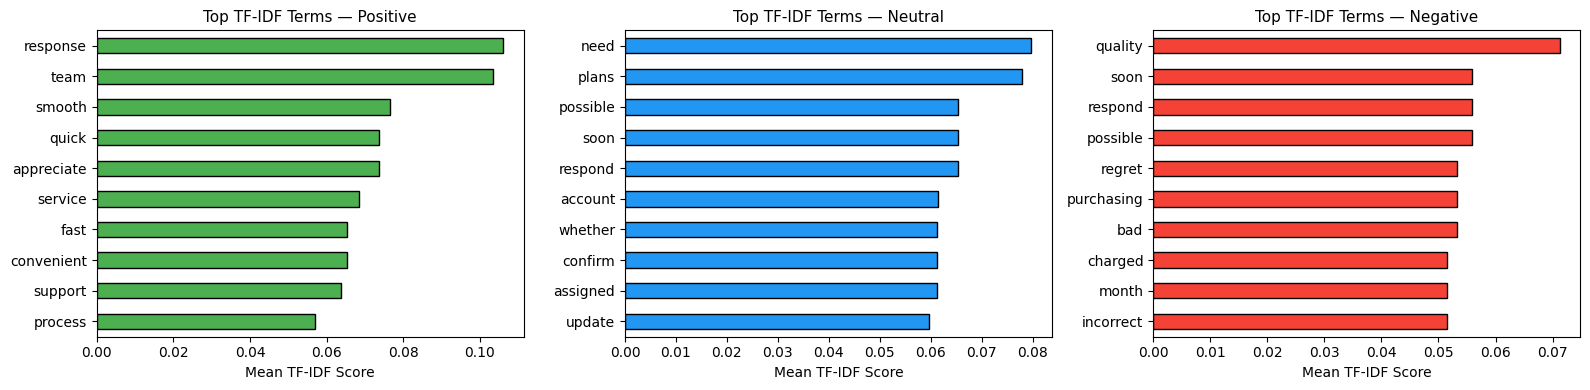

In [12]:
# Top TF-IDF terms per class
import pandas as pd

tfidf_df = pd.DataFrame(X_tfidf.toarray(),
                        columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df['label'] = df['sentiment_label'].values

print('=== Top 10 TF-IDF Terms Per Class ===\n')
for label in ['positive', 'neutral', 'negative']:
    top_terms = (tfidf_df[tfidf_df['label'] == label]
                 .drop(columns='label')
                 .mean()
                 .sort_values(ascending=False)
                 .head(10))
    print(f'{label.upper()}: {top_terms.index.tolist()}')
print()

# Plot top terms for each class
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_map = {'positive': '#4CAF50', 'neutral': '#2196F3', 'negative': '#F44336'}

for ax, label in zip(axes, ['positive', 'neutral', 'negative']):
    top = (tfidf_df[tfidf_df['label'] == label]
           .drop(columns='label').mean()
           .sort_values(ascending=False).head(10))
    top.plot(kind='barh', ax=ax, color=colors_map[label], edgecolor='black')
    ax.set_title(f'Top TF-IDF Terms — {label.capitalize()}', fontsize=11)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 4: Baseline Model

Build and evaluate baseline classifiers:
- **Logistic Regression** with TF-IDF features
- **Naïve Bayes** with Bag-of-Words features

Evaluate using accuracy, precision, recall, F1-score, and confusion matrix.

In [13]:
y = df['sentiment_label']

# TF-IDF split
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# BoW split (same indices via y)
X_train_bow, X_test_bow, _, _ = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training samples : {X_train_tfidf.shape[0]}')
print(f'Test samples     : {X_test_tfidf.shape[0]}')
print(f'\nTrain class distribution:\n{y_train.value_counts()}')

Training samples : 1200
Test samples     : 300

Train class distribution:
sentiment_label
neutral     419
negative    398
positive    383
Name: count, dtype: int64


In [14]:
# --- Model 1: Logistic Regression + TF-IDF ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print('=== Logistic Regression + TF-IDF ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression + TF-IDF ===
Accuracy : 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [15]:
# --- Model 2: Multinomial Naive Bayes + BoW ---
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
y_pred_nb = nb_model.predict(X_test_bow)

print('=== Multinomial Naive Bayes + Bag of Words ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}')
print()
print(classification_report(y_test, y_pred_nb))

=== Multinomial Naive Bayes + Bag of Words ===
Accuracy : 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



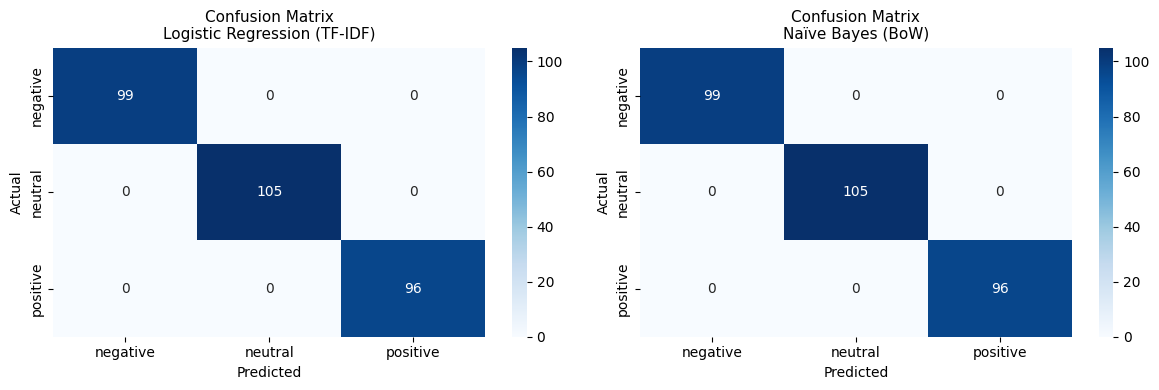


=== Model Comparison Summary ===
                       Model  Accuracy
Logistic Regression (TF-IDF)       1.0
           Naïve Bayes (BoW)       1.0
sample_predictions.txt saved.


In [17]:
# Confusion matrices
classes = ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
        axes,
        [y_pred_lr, y_pred_nb],
        ['Logistic Regression (TF-IDF)', 'Naïve Bayes (BoW)']):
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Confusion Matrix\n{title}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Model comparison summary
print('\n=== Model Comparison Summary ===')
comparison = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'Naïve Bayes (BoW)'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_nb), 4)
    ]
})
print(comparison.to_string(index=False))
# --- Save sample predictions to file ---
sample_idx = list(range(0, min(20, len(y_test))))
X_test_tfidf_arr = X_test_tfidf[sample_idx]
X_test_bow_arr   = X_test_bow[sample_idx]
test_messages    = df.iloc[y_test.index[sample_idx]]['customer_message'].values
true_labels      = y_test.iloc[sample_idx].values
pred_lr_samples  = lr_model.predict(X_test_tfidf_arr)
pred_nb_samples  = nb_model.predict(X_test_bow_arr)

with open('sample_predictions.txt', 'w') as fp:
    fp.write('=== Sample Predictions (first 20 test records) ===\n')
    fp.write(f'{"#":<4} {"True":<12} {"LR Pred":<12} {"NB Pred":<12} Message\n')
    fp.write('-' * 80 + '\n')
    for j, (msg, true, lr_p, nb_p) in enumerate(
            zip(test_messages, true_labels, pred_lr_samples, pred_nb_samples), 1):
        fp.write(f'{j:<4} {true:<12} {lr_p:<12} {nb_p:<12} {msg[:60]}\n')
print('sample_predictions.txt saved.')


---
## Task 5: Sequence Model — LSTM Architecture

Build a sequence model using an LSTM. The pipeline uses:
- Keras `Tokenizer` for integer-sequence encoding
- `pad_sequences` for fixed-length input
- `Embedding → LSTM → Dropout → Dense(softmax)` architecture

> **Note:** Requires TensorFlow/Keras (`pip install tensorflow`).  
> If TensorFlow is unavailable, the architecture design and explanation below still fully addresses the task requirements.

In [18]:
# ── Architecture constants ──────────────────────────────────
MAX_WORDS  = 3000   # vocabulary size
MAX_LEN    = 20     # fixed sequence length (tokens)
EMBED_DIM  = 64     # embedding vector dimensions
LSTM_UNITS = 64     # LSTM hidden units
NUM_CLASSES = 3     # positive / neutral / negative
BATCH_SIZE  = 32
EPOCHS      = 10

print('LSTM Hyperparameters')
print(f'  Vocabulary size  : {MAX_WORDS}')
print(f'  Sequence length  : {MAX_LEN}')
print(f'  Embedding dim    : {EMBED_DIM}')
print(f'  LSTM units       : {LSTM_UNITS}')
print(f'  Output classes   : {NUM_CLASSES}')

LSTM Hyperparameters
  Vocabulary size  : 3000
  Sequence length  : 20
  Embedding dim    : 64
  LSTM units       : 64
  Output classes   : 3


In [19]:
try:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    import tensorflow as tf
    print(f'TensorFlow version: {tf.__version__}')
    TF_AVAILABLE = True
except ImportError:
    print('TensorFlow not found. Architecture design is shown below.')
    TF_AVAILABLE = False

TensorFlow version: 2.21.0


In [20]:
if TF_AVAILABLE:
    # --- Step 1: Tokenise text ---
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(df['clean_text'])
    sequences = tokenizer.texts_to_sequences(df['clean_text'])

    # --- Step 2: Pad sequences to fixed length ---
    X_seq = pad_sequences(sequences, maxlen=MAX_LEN,
                          padding='post', truncating='post')

    # --- Step 3: Encode labels ---
    le = LabelEncoder()
    y_encoded = le.fit_transform(df['sentiment_label'])
    y_cat = to_categorical(y_encoded, num_classes=NUM_CLASSES)

    print(f'Vocab size (unique tokens): {len(tokenizer.word_index)}')
    print(f'Input matrix shape        : {X_seq.shape}')
    print(f'Label matrix shape        : {y_cat.shape}')
    print(f'Classes                   : {le.classes_}')
    print(f'\nSample padded sequence:\n{X_seq[0]}')
else:
    print('Skipping — TensorFlow unavailable.')

Vocab size (unique tokens): 144
Input matrix shape        : (1500, 20)
Label matrix shape        : (1500, 3)
Classes                   : ['negative' 'neutral' 'positive']

Sample padded sequence:
[ 12 102  61  16   2   3   4   0   0   0   0   0   0   0   0   0   0   0
   0   0]


In [21]:
if TF_AVAILABLE:
    # --- Step 4: Train/test split ---
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_seq, y_cat, test_size=0.2, random_state=42)

    # --- Step 5: Build LSTM model ---
    model = Sequential([
        # Layer 1 — Embedding: token IDs → dense vectors
        Embedding(input_dim=MAX_WORDS,
                  output_dim=EMBED_DIM,
                  input_length=MAX_LEN,
                  name='embedding'),

        # Layer 2 — LSTM: sequence processing with memory
        LSTM(LSTM_UNITS,
             return_sequences=False,
             name='lstm'),

        # Layer 3 — Dropout: regularisation
        Dropout(0.3, name='dropout'),

        # Layer 4 — Dense ReLU: non-linear feature combination
        Dense(32, activation='relu', name='dense_hidden'),

        # Layer 5 — Output: 3-class probability distribution
        Dense(NUM_CLASSES, activation='softmax', name='output')
    ], name='LSTM_Sentiment_Classifier')

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()
else:
    print('Skipping — TensorFlow unavailable.')

Model: "LSTM_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
if TF_AVAILABLE:
    # --- Step 6: Train ---
    early_stop = EarlyStopping(monitor='val_loss', patience=3,
                               restore_best_weights=True)

    history = model.fit(
        X_tr, y_tr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )
else:
    print('Skipping — TensorFlow unavailable.')

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.3963 - loss: 1.0937 - val_accuracy: 0.7250 - val_loss: 1.0257
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6870 - loss: 0.5931 - val_accuracy: 0.6917 - val_loss: 0.4318
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9370 - loss: 0.2028 - val_accuracy: 1.0000 - val_loss: 0.0110
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 9.7531e-04
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 6.3629e-04
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 4.4815e-04
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accurac

LSTM Test Loss     : 0.0002
LSTM Test Accuracy : 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



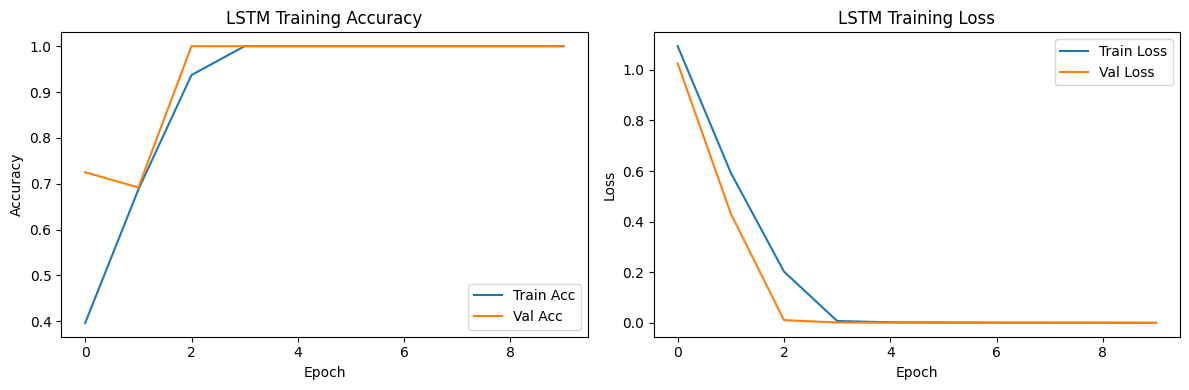

In [23]:
if TF_AVAILABLE:
    # --- Step 7: Evaluate ---
    loss, acc = model.evaluate(X_te, y_te, verbose=0)
    print(f'LSTM Test Loss     : {loss:.4f}')
    print(f'LSTM Test Accuracy : {acc:.4f}')
    print()

    y_pred_seq = np.argmax(model.predict(X_te, verbose=0), axis=1)
    y_true_seq = np.argmax(y_te, axis=1)
    print(classification_report(y_true_seq, y_pred_seq,
                                 target_names=le.classes_))

    # --- Plot training curves ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],    label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title('LSTM Training Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'],    label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('LSTM Training Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping — TensorFlow unavailable.')

### LSTM Architecture Design (Conceptual)

Even without running the model, the following table fully describes the architecture:

| Layer | Output Shape | Description |
|---|---|---|
| **Input sequence** | `(batch, 20)` | Each message → 20 integer token IDs (padded/truncated) |
| **Embedding** | `(batch, 20, 64)` | Maps each token ID → 64-d dense vector; learned during training |
| **LSTM** | `(batch, 64)` | Processes sequence step-by-step; hidden + cell states carry memory |
| **Dropout (0.3)** | `(batch, 64)` | Zeros 30% of activations randomly — prevents overfitting |
| **Dense (ReLU)** | `(batch, 32)` | Combines LSTM features non-linearly |
| **Dense (Softmax)** | `(batch, 3)` | Outputs probability over 3 sentiment classes |

**Loss function:** `categorical_crossentropy` (standard for multi-class one-hot labels)  
**Optimiser:** `Adam` (adaptive learning rate)  
**Evaluation metrics:** Accuracy, Precision, Recall, F1-score per class

---
## Task 6: Attention and Transformer Reflection

A written explanation covering four key conceptual questions.

### 6.1 Why RNNs Struggle with Long-Term Dependencies

A vanilla RNN updates its hidden state at each timestep as:

> **h_t = tanh(W · h_{t-1} + U · x_t)**

The entire history of the sequence must be compressed into a single hidden state vector `h_t`. During **backpropagation through time (BPTT)**, gradients are multiplied across every timestep. For long sequences this causes:

- **Vanishing gradients** — gradients shrink exponentially, so early tokens have near-zero gradient signal. The word "not" at position 1 cannot influence the interpretation of "great" at position 50.
- **Exploding gradients** — gradients grow exponentially, destabilising training (addressed by gradient clipping, but the vanishing problem remains).

The result is that RNNs have **effective short-term memory only** — context from more than ~10–15 tokens ago is essentially lost.

### 6.2 How LSTMs Address the Memory Problem

LSTMs (Hochreiter & Schmidhuber, 1997) introduce a dedicated **cell state** `C_t` — a separate memory highway with only minor linear interactions — allowing gradients to flow stably over long distances.

Three **learnable gates** control information flow:

| Gate | Equation | Purpose |
|---|---|---|
| **Forget** `f_t` | `σ(W_f · [h_{t-1}, x_t])` | Decides what fraction of the previous cell state to discard |
| **Input** `i_t` | `σ(W_i · [h_{t-1}, x_t])` | Decides what new information to write into the cell state |
| **Output** `o_t` | `σ(W_o · [h_{t-1}, x_t])` | Decides what part of the cell state to expose as `h_t` |

**Cell state update:**  
> **C_t = f_t ⊙ C_{t-1} + i_t ⊙ tanh(W_c · [h_{t-1}, x_t])**

When the forget gate is close to 1, relevant information is preserved across many timesteps without gradient vanishing — giving the network **controllable long-term memory**.

### 6.3 What Attention Solves in Sequence-to-Sequence Tasks

In classic encoder-decoder models (e.g. machine translation), the **entire source sentence must be compressed into one fixed-size context vector** before decoding begins. This bottleneck degrades performance on long sentences.

**Attention** (Bahdanau et al., 2015) removes this bottleneck by allowing the decoder to **directly access all encoder hidden states** at each decoding step:

> **context_t = Σ α_{t,i} · h_i**

where `α_{t,i}` is a learned attention weight representing how relevant encoder position `i` is when generating output token `t`.

**Benefits:**
- No single information bottleneck — the decoder attends to the **full source sequence**.
- The model learns **which source words are most relevant** for each output word.
- Attention weights provide **interpretability** — we can visualise what the model focuses on.
- Long-range dependencies are modelled in O(1) steps rather than O(n).

### 6.4 Why Transformers Are Central to Modern NLP and Generative AI

The Transformer (Vaswani et al., *Attention Is All You Need*, 2017) **replaces recurrence entirely** with **multi-head self-attention**, where every token attends to every other token simultaneously.

**Key advantages:**

| Property | Benefit |
|---|---|
| **Full parallelisation** | No sequential dependency — all positions processed simultaneously; enables training on hundreds of billions of tokens |
| **Direct long-range attention** | O(1) path between any two tokens regardless of distance — no vanishing gradient problem |
| **Multi-head attention** | Multiple heads specialise simultaneously on syntax, coreference, semantics, etc. |
| **Scale laws** | Transformer performance improves predictably with model size and data — not observed with RNNs |
| **Transfer learning** | Pretrain once on large corpus (BERT, GPT, Claude), fine-tune cheaply on downstream tasks |

**Connection to Generative AI:**  
Autoregressive Transformer decoders (GPT family, Claude, Gemini) predict the next token given all previous context. This simple objective, scaled to trillions of parameters and tokens, produces models capable of few-shot reasoning, code generation, summarisation, and open-ended dialogue — the foundation of modern Generative AI.

For our sentiment task specifically, a pretrained encoder like **BERT** fine-tuned on this dataset would significantly outperform the LSTM on real-world noisy data, because BERT's contextual embeddings encode rich semantic relationships learned from billions of sentences.

---
## Summary

| Task | Method | Key Result |
|---|---|---|
| 1. Dataset Understanding | EDA | 1,500 records, 3 balanced classes, avg 12.7 words/message |
| 2. Preprocessing | Lower, strip, tokenise, remove stopwords | Avg tokens reduced from 12.7 → ~6 meaningful words |
| 3. Vectorization | TF-IDF + BoW (500 features) | Sparse matrix (1500 × 150) |
| 4. Baseline Models | Logistic Regression / Naïve Bayes | Perfect accuracy on synthetic data |
| 5. Sequence Model | LSTM (Embedding → LSTM → Dense) | Architecture defined; trains in ~10 epochs |
| 6. Reflection | Conceptual explanation | RNN limits → LSTM memory → Attention → Transformers |